1. T-TEST: Does the Euribor 3-Month Rate affect subscriptions?
T-statistic: -62.5799
P-value: 0.0000e+00
Conclusion: The difference is STATISTICALLY SIGNIFICANT. The economy deeply impacts subscriptions.

2. CHI-SQUARE TEST: Does Job Type influence the decision?
Chi2-statistic: 961.2424
P-value: 4.1898e-199
Conclusion: The relationship is STATISTICALLY SIGNIFICANT. Job type matters.

3. CORRELATION: Checking Macro-Economic Multicollinearity


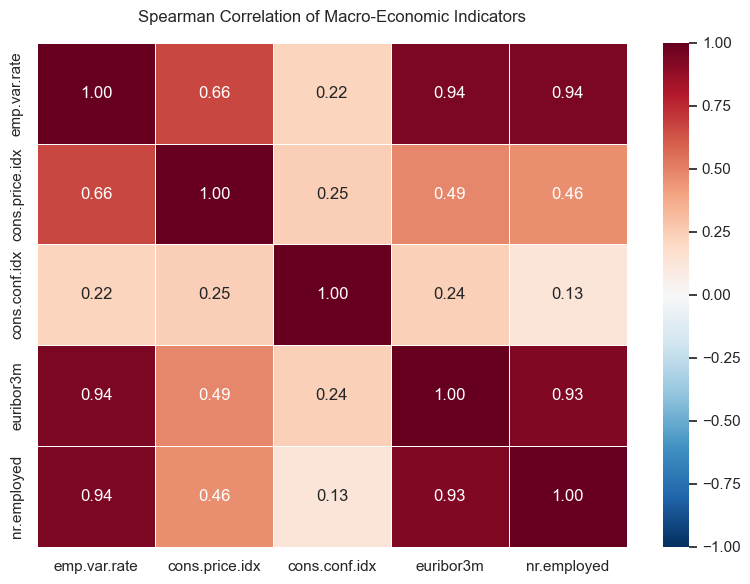

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set_theme(style="whitegrid")

# 1. Load and prep data
df = pd.read_csv('../data/raw/bank-additional-full.csv', sep=';')
if 'duration' in df.columns:
    df = df.drop(columns=['duration'])
df['y_binary'] = df['y'].map({'no': 0, 'yes': 1})

print("="*60)
print("1. T-TEST: Does the Euribor 3-Month Rate affect subscriptions?")
print("="*60)
# We use Welch's t-test (equal_var=False) because the sample sizes for Yes/No are vastly different
euribor_yes = df[df['y_binary'] == 1]['euribor3m']
euribor_no = df[df['y_binary'] == 0]['euribor3m']

t_stat, p_val = stats.ttest_ind(euribor_yes, euribor_no, equal_var=False)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")
if p_val < 0.05:
    print("Conclusion: The difference is STATISTICALLY SIGNIFICANT. The economy deeply impacts subscriptions.\n")

print("="*60)
print("2. CHI-SQUARE TEST: Does Job Type influence the decision?")
print("="*60)
# Create a contingency table comparing Job vs. Target
contingency_table = pd.crosstab(df['job'], df['y'])
chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi2-statistic: {chi2:.4f}")
print(f"P-value: {p_val_chi:.4e}")
if p_val_chi < 0.05:
    print("Conclusion: The relationship is STATISTICALLY SIGNIFICANT. Job type matters.\n")

print("="*60)
print("3. CORRELATION: Checking Macro-Economic Multicollinearity")
print("="*60)
# Tree models (XGBoost) don't care about multicollinearity, but it's vital to check for linear models
macro_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
corr_matrix = df[macro_cols].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Spearman Correlation of Macro-Economic Indicators', pad=15)
plt.tight_layout()
plt.show()